In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA


In [34]:
df = pd.read_csv('bank_transactions.csv')
df.head()
df.info()

df['Gender'] = (df['CustGender'] == 'F').astype(int)

customer_df = df.groupby('CustomerID').agg(
    TotalTransactions = ('TransactionAmount (INR)', 'count'),
    TotalSpend        = ('TransactionAmount (INR)', 'sum'),
    AvgTransactionAmt = ('TransactionAmount (INR)', 'mean'),
    AvgAccountBalance = ('CustAccountBalance', 'mean'),
    Gender            = ('Gender', 'first')
).reset_index()

customer_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  str    
 1   CustomerID               1048567 non-null  str    
 2   CustomerDOB              1045170 non-null  str    
 3   CustGender               1047467 non-null  str    
 4   CustLocation             1048416 non-null  str    
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  str    
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), str(6)
memory usage: 72.0 MB


,CustomerID,TotalTransactions,TotalSpend,AvgTransactionAmt,AvgAccountBalance,Gender
0,C1010011,2,5106.0,2553.0,76340.635,1
1,C1010012,1,1499.0,1499.0,24204.490,0
2,C1010014,2,1455.0,727.5,100112.950,1
3,C1010018,1,30.0,30.0,496.180,1
4,C1010024,1,5000.0,5000.0,87058.650,0


In [35]:
cluster_df = customer_df[
    [
        'TotalTransactions',
        'TotalSpend',
        'AvgTransactionAmt',
        'AvgAccountBalance',
        'Gender'
    ]
].copy()

cluster_df.head()
cluster_df.isnull().sum()
cluster_df = cluster_df.fillna(cluster_df.median())


In [36]:
SAMPLE_SIZE = 5000
cluster_df = cluster_df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)


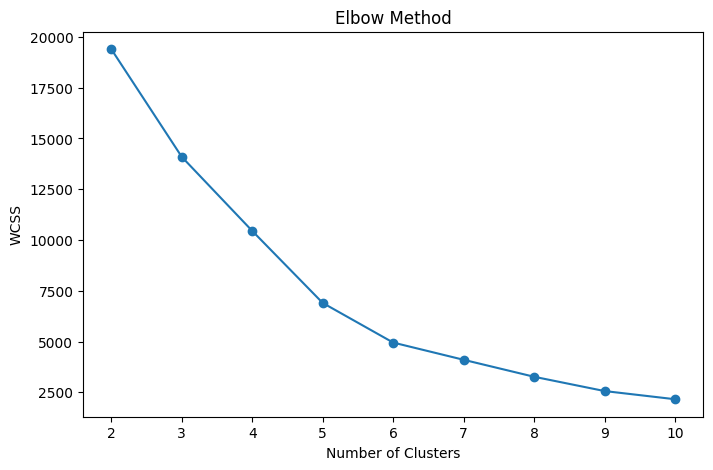

In [37]:
wcss = []

for i in range(2, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


In [38]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(scaled_data)

sil_kmeans = silhouette_score(scaled_data, kmeans_labels)
db_kmeans = davies_bouldin_score(scaled_data, kmeans_labels)
ch_kmeans = calinski_harabasz_score(scaled_data, kmeans_labels)

print("Silhouette Score :", sil_kmeans)
print("Davies-Bouldin Score :", db_kmeans)
print("Calinski-Harabasz Score :", ch_kmeans)


Silhouette Score : 0.7417535997910443
Davies-Bouldin Score : 0.4916157387540908
Calinski-Harabasz Score : 3275.037048502493


In [39]:
cluster_df['KMeans_Cluster'] = kmeans_labels
cluster_df.head()


,TotalTransactions,TotalSpend,AvgTransactionAmt,AvgAccountBalance,Gender,KMeans_Cluster
0,1,271.44,271.44,705797.95,0,0
1,1,649.00,649.00,48444.65,0,0
2,1,114.00,114.00,45546.50,0,0
3,1,296.00,296.00,116236.58,0,0
4,1,397.00,397.00,12529.26,0,0


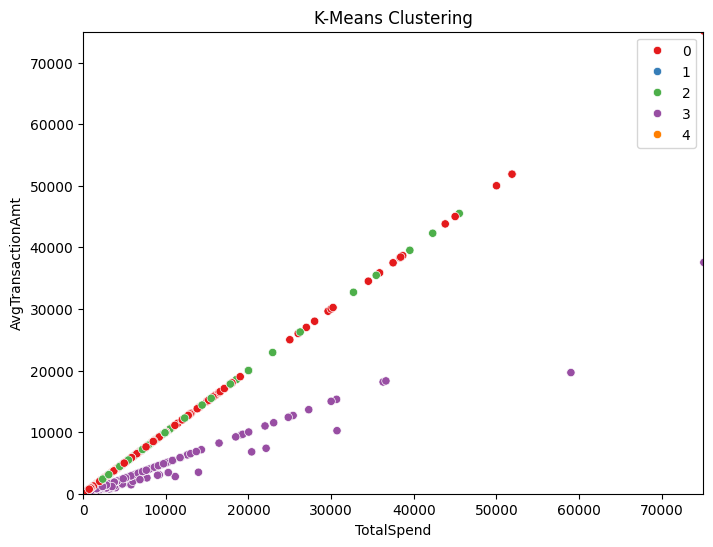

In [40]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=cluster_df['TotalSpend'],
    y=cluster_df['AvgTransactionAmt'],
    hue=kmeans_labels,
    palette='Set1'
)
plt.xlim(0, 75000)
plt.ylim(0, 75000)

plt.title('K-Means Clustering')
plt.show()


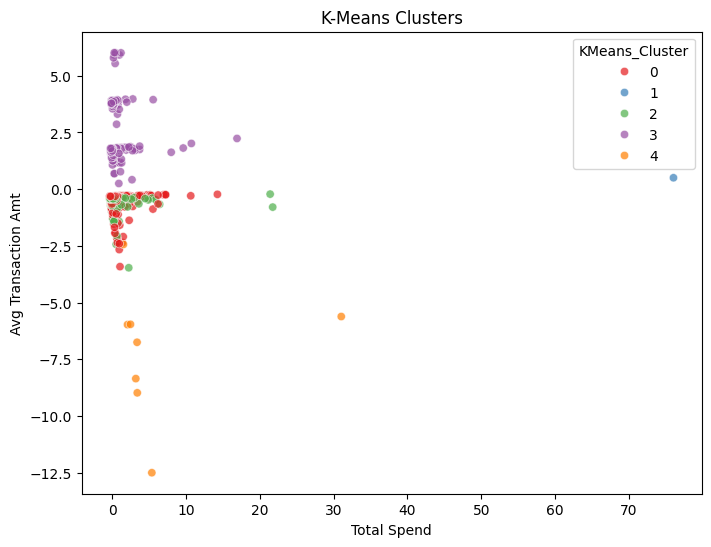

In [51]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=cluster_df['KMeans_Cluster'], 
    palette='Set1',
    alpha=0.7 
)

plt.title('K-Means Clusters')
plt.xlabel('Total Spend')
plt.ylabel('Avg Transaction Amt')
plt.show()

In [42]:
hc = AgglomerativeClustering(
    n_clusters=5
)
hc_labels = hc.fit_predict(scaled_data)

sil_hc = silhouette_score(scaled_data, hc_labels)
db_hc = davies_bouldin_score(scaled_data, hc_labels)
ch_hc = calinski_harabasz_score(scaled_data, hc_labels)

print("Silhouette Score :", sil_hc)
print("Davies-Bouldin Score :", db_hc)
print("Calinski-Harabasz Score :", ch_hc)


Silhouette Score : 0.7359895106765165
Davies-Bouldin Score : 0.751946758056636
Calinski-Harabasz Score : 2929.3369181574735


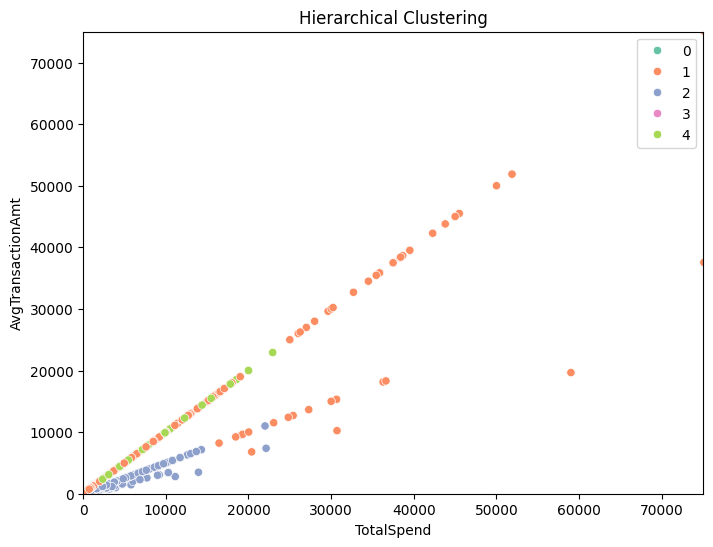

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=cluster_df['TotalSpend'],
    y=cluster_df['AvgTransactionAmt'],
    hue=hc_labels,
    palette='Set2'
)
plt.xlim(0, 75000)
plt.ylim(0, 75000)

plt.title('Hierarchical Clustering')
plt.show()


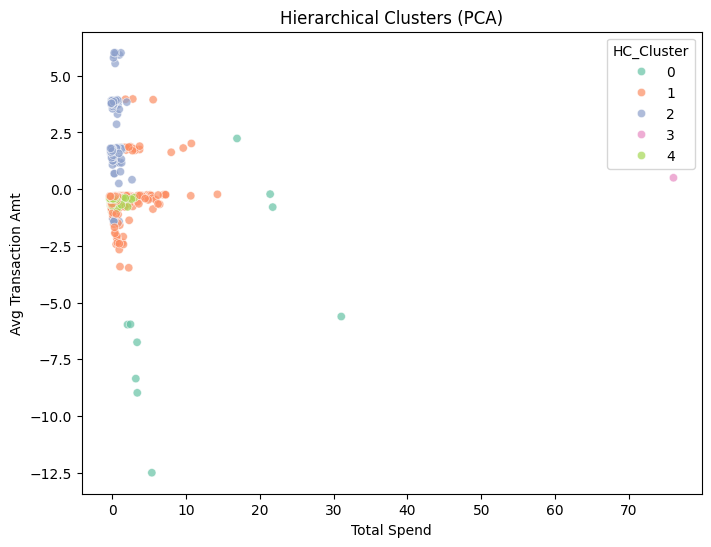

In [44]:
# 1. Add Hierarchical labels to the dataframe
cluster_df['HC_Cluster'] = hc_labels

# 2. PCA Scatter Plot for Hierarchical
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=cluster_df['HC_Cluster'], 
    palette='Set2',
    alpha=0.7 
)
plt.title('Hierarchical Clusters (PCA)')
plt.xlabel('Total Spend')
plt.ylabel('Avg Transaction Amt')
plt.show()


In [45]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(scaled_data)
np.unique(dbscan_labels)


array([-1,  0,  1,  2,  3,  4,  5])

In [46]:
if len(np.unique(dbscan_labels)) > 1:
    sil_dbscan = silhouette_score(scaled_data, dbscan_labels)
    db_dbscan = davies_bouldin_score(scaled_data, dbscan_labels)
    ch_dbscan = calinski_harabasz_score(scaled_data, dbscan_labels)

    print("Silhouette Score:", sil_dbscan)
    print("Davies-Bouldin Score:", db_dbscan)
    print("Calinski-Harabasz Score:", ch_dbscan)
else:
    sil_dbscan, db_dbscan, ch_dbscan = np.nan, np.nan, np.nan
    print("Only one cluster found. Try adjusting eps or min_samples.")


Silhouette Score: 0.8248360382160883
Davies-Bouldin Score: 1.2774839087498253
Calinski-Harabasz Score: 805.7986994941178


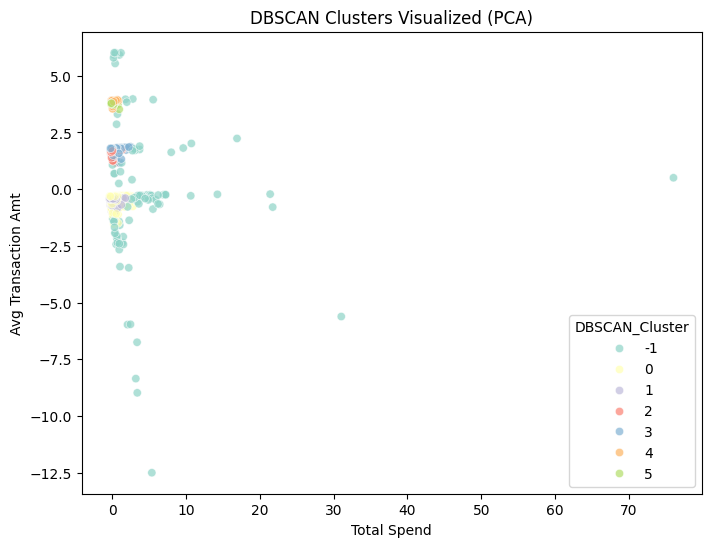

In [47]:
# 1. Add DBSCAN labels to the dataframe
cluster_df['DBSCAN_Cluster'] = dbscan_labels

# 2. PCA Scatter Plot for DBSCAN
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_features[:, 0],
    y=pca_features[:, 1],
    hue=cluster_df['DBSCAN_Cluster'], 
    palette='Set3',
    alpha=0.7 
)
plt.title('DBSCAN Clusters Visualized (PCA)')
plt.xlabel('Total Spend')
plt.ylabel('Avg Transaction Amt')
plt.show()


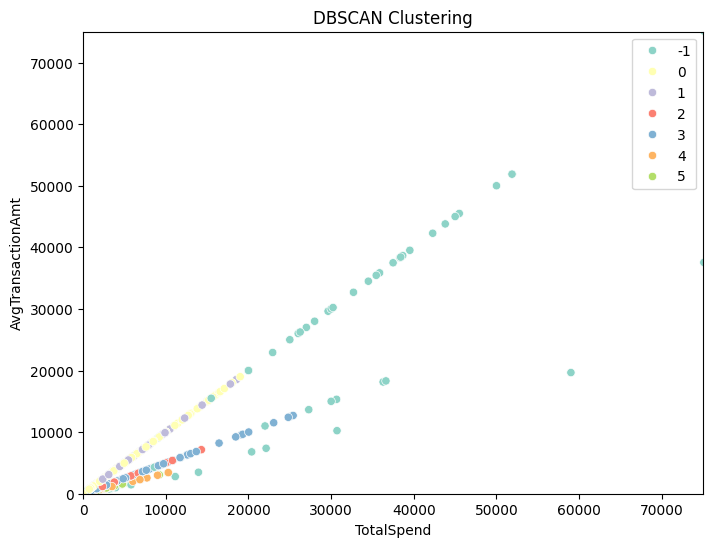

In [53]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=cluster_df['TotalSpend'],
    y=cluster_df['AvgTransactionAmt'],
    hue=dbscan_labels,
    palette='Set3'
)
plt.xlim(0, 75000)
plt.ylim(0, 75000)

plt.title('DBSCAN Clustering')
plt.show()


In [49]:
metrics_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Silhouette Score': [sil_kmeans, sil_hc, sil_dbscan],
    'Davies-Bouldin Score': [db_kmeans, db_hc, db_dbscan],
    'Calinski-Harabasz Score': [ch_kmeans, ch_hc, ch_dbscan]
})

metrics_df

,Algorithm,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,K-Means,0.741754,0.491616,3275.037049
1,Hierarchical,0.735990,0.751947,2929.336918
2,DBSCAN,0.824836,1.277484,805.798699
